# 3 - Dissonance + Chromaticism

## Imports

In [117]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

## Load Data

In [121]:
metadata = g.load_metadata()
metadata = g.load_keys(metadata)

In [122]:
major_metadata = metadata[metadata['key'].str.contains('major', na=False)]
minor_metadata = metadata[metadata['key'].str.contains('minor', na=False)]

## In-Label Dissonance

In [202]:
ILC_major_raw = g.load_labels(major_metadata)
ILC_minor_raw = g.load_labels(minor_metadata)

In [210]:
ILC_major = ILC_major_raw.copy()
ILC_minor = ILC_minor_raw.copy()

# Major: Calculate duration-weighted average dissonance for each piece
ILC_major['dissonance'] = ILC_major['label'].apply(ia.label_to_dissonance)

ILC_major['dissonance'] = ILC_major['dissonance'] * ILC_major['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
ILC_major = ILC_major.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].sum()
ILC_major['dissonance'] = ILC_major['dissonance'] / ILC_major['duration_qb']

# Minor: Calculate duration-weighted average dissonance for each piece
ILC_minor['dissonance'] = ILC_minor['label'].apply(ia.label_to_dissonance)

ILC_minor['dissonance'] = ILC_minor['dissonance'] * ILC_minor['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
ILC_minor = ILC_minor.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].sum()
ILC_minor['dissonance'] = ILC_minor['dissonance'] / ILC_minor['duration_qb']


/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:564: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:565: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:576: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/

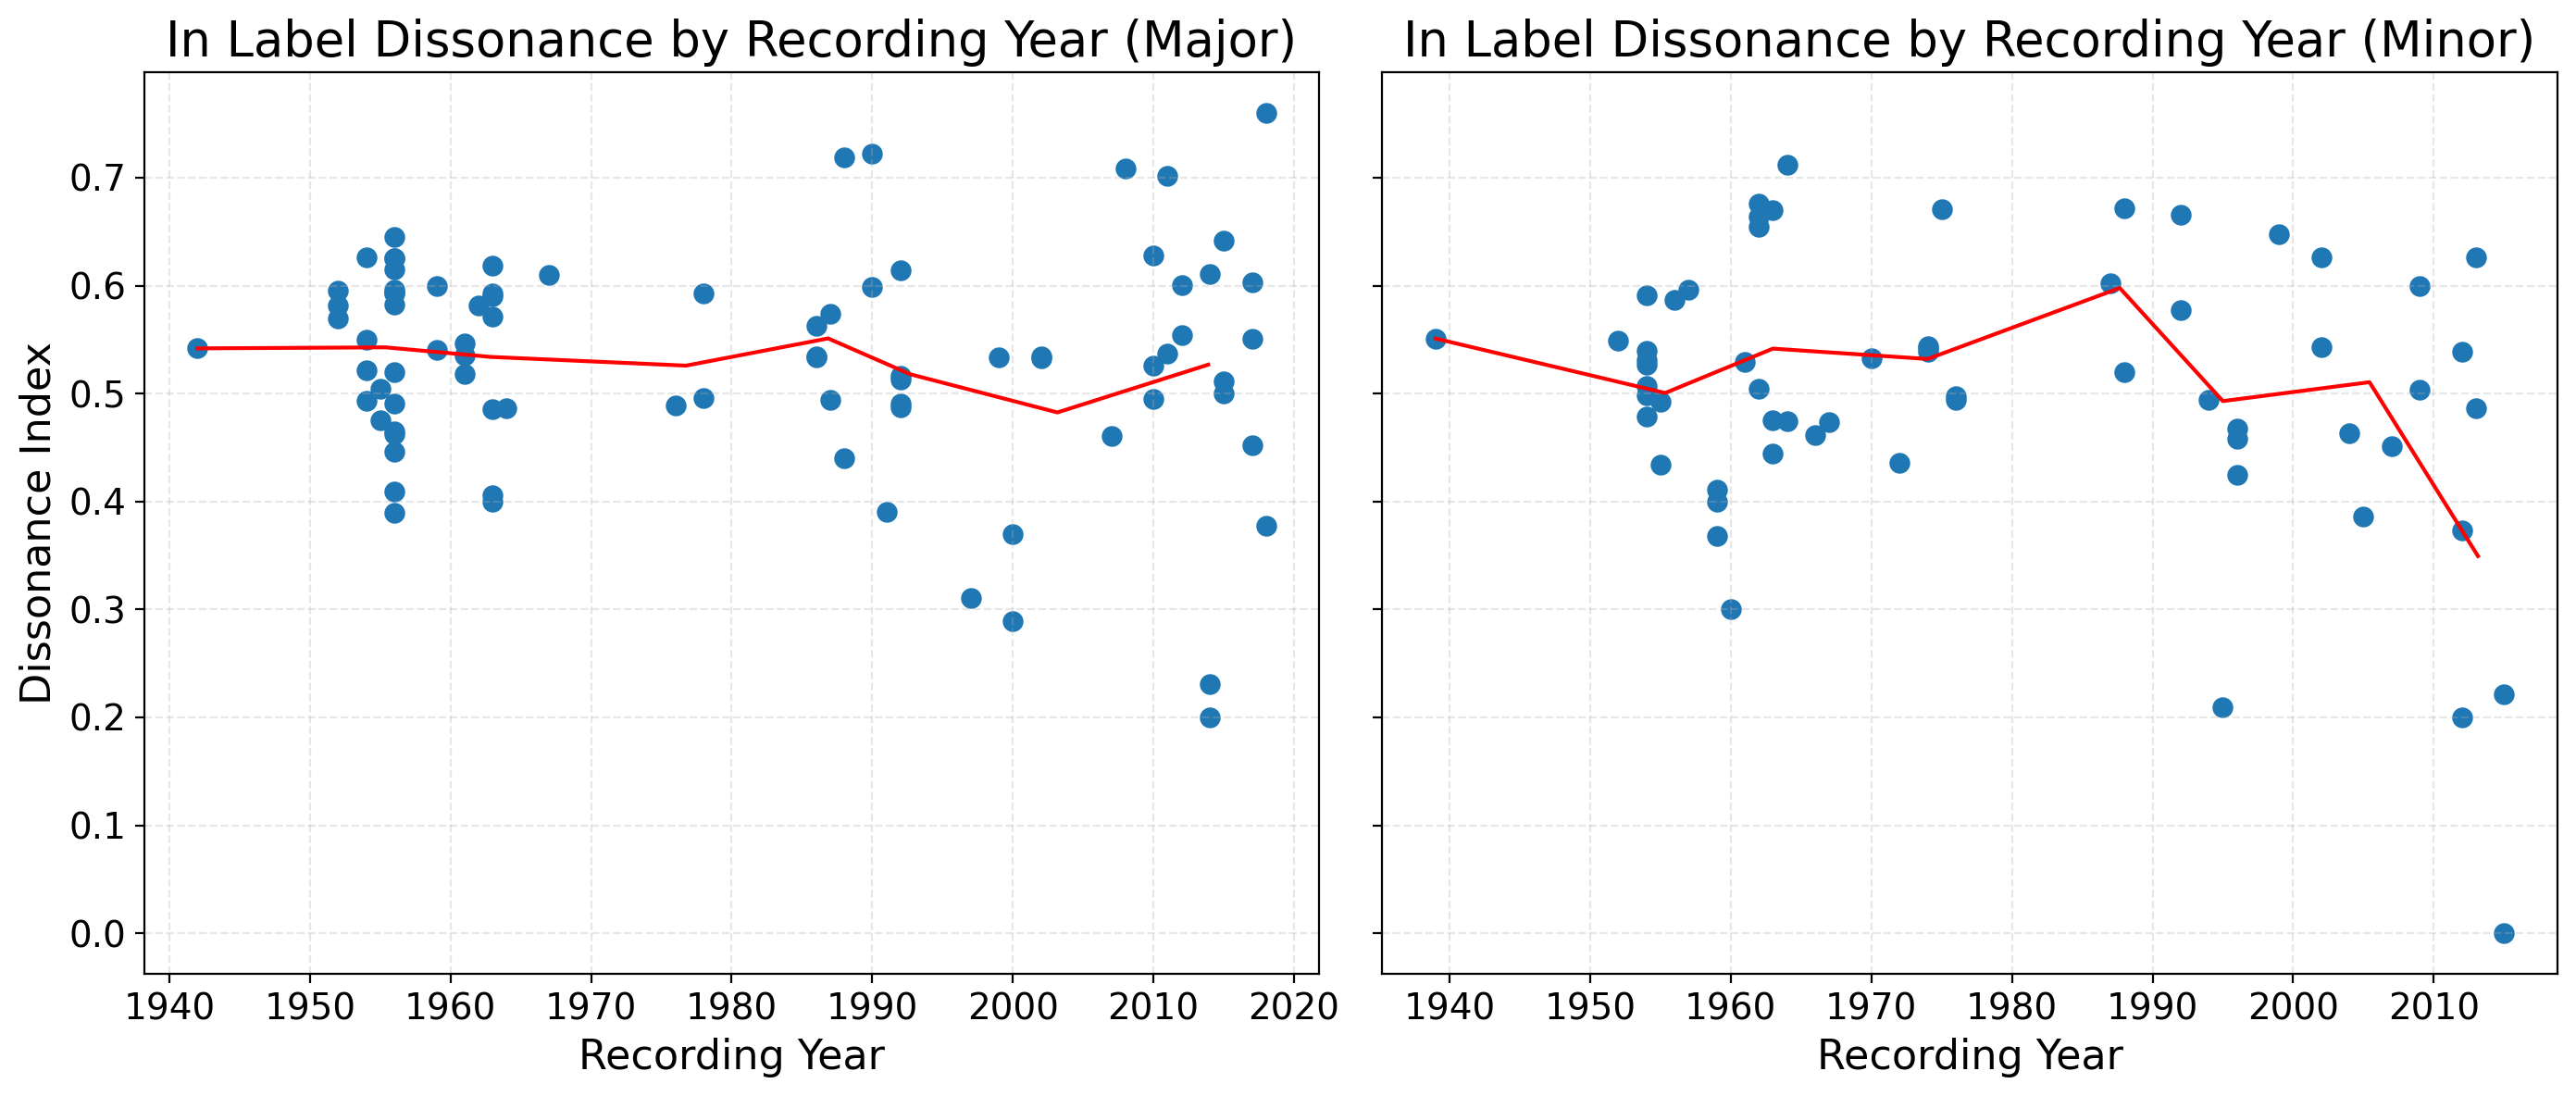

In [297]:
title = 'In Label Dissonance by Recording Year'
fig,ax = ia.plot_dissonance(ILC_major, ILC_minor, title)

plt.tight_layout()
#plt.savefig(f"../Results/AvgInLabelDissonanceIndex")
plt.show()

## Sounding Dissonance

In [216]:
harmonies_major_raw = g.load_harmonies(major_metadata)
harmonies_minor_raw = g.load_harmonies(minor_metadata) 

In [223]:
harmonies_major = harmonies_major_raw.copy()
harmonies_minor = harmonies_minor_raw.copy() 

# Major: Calculate duration-weighted average dissonance for each piece
harmonies_major['dissonance'] = harmonies_major['semitones'].apply(ia.semitones_to_dissonance)

harmonies_major['dissonance'] = harmonies_major['dissonance'] * harmonies_major['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
harmonies_major = harmonies_major.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].mean()
harmonies_major['dissonance'] = harmonies_major['dissonance'] / harmonies_major['duration_qb']

# Minor: Calculate duration-weighted average dissonance for each piece
harmonies_minor['dissonance'] = harmonies_minor['semitones'].apply(ia.semitones_to_dissonance)

harmonies_minor['dissonance'] = harmonies_minor['dissonance'] * harmonies_minor['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
harmonies_minor = harmonies_minor.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].mean()
harmonies_minor['dissonance'] = harmonies_minor['dissonance'] / harmonies_minor['duration_qb']

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:564: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:565: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:576: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/

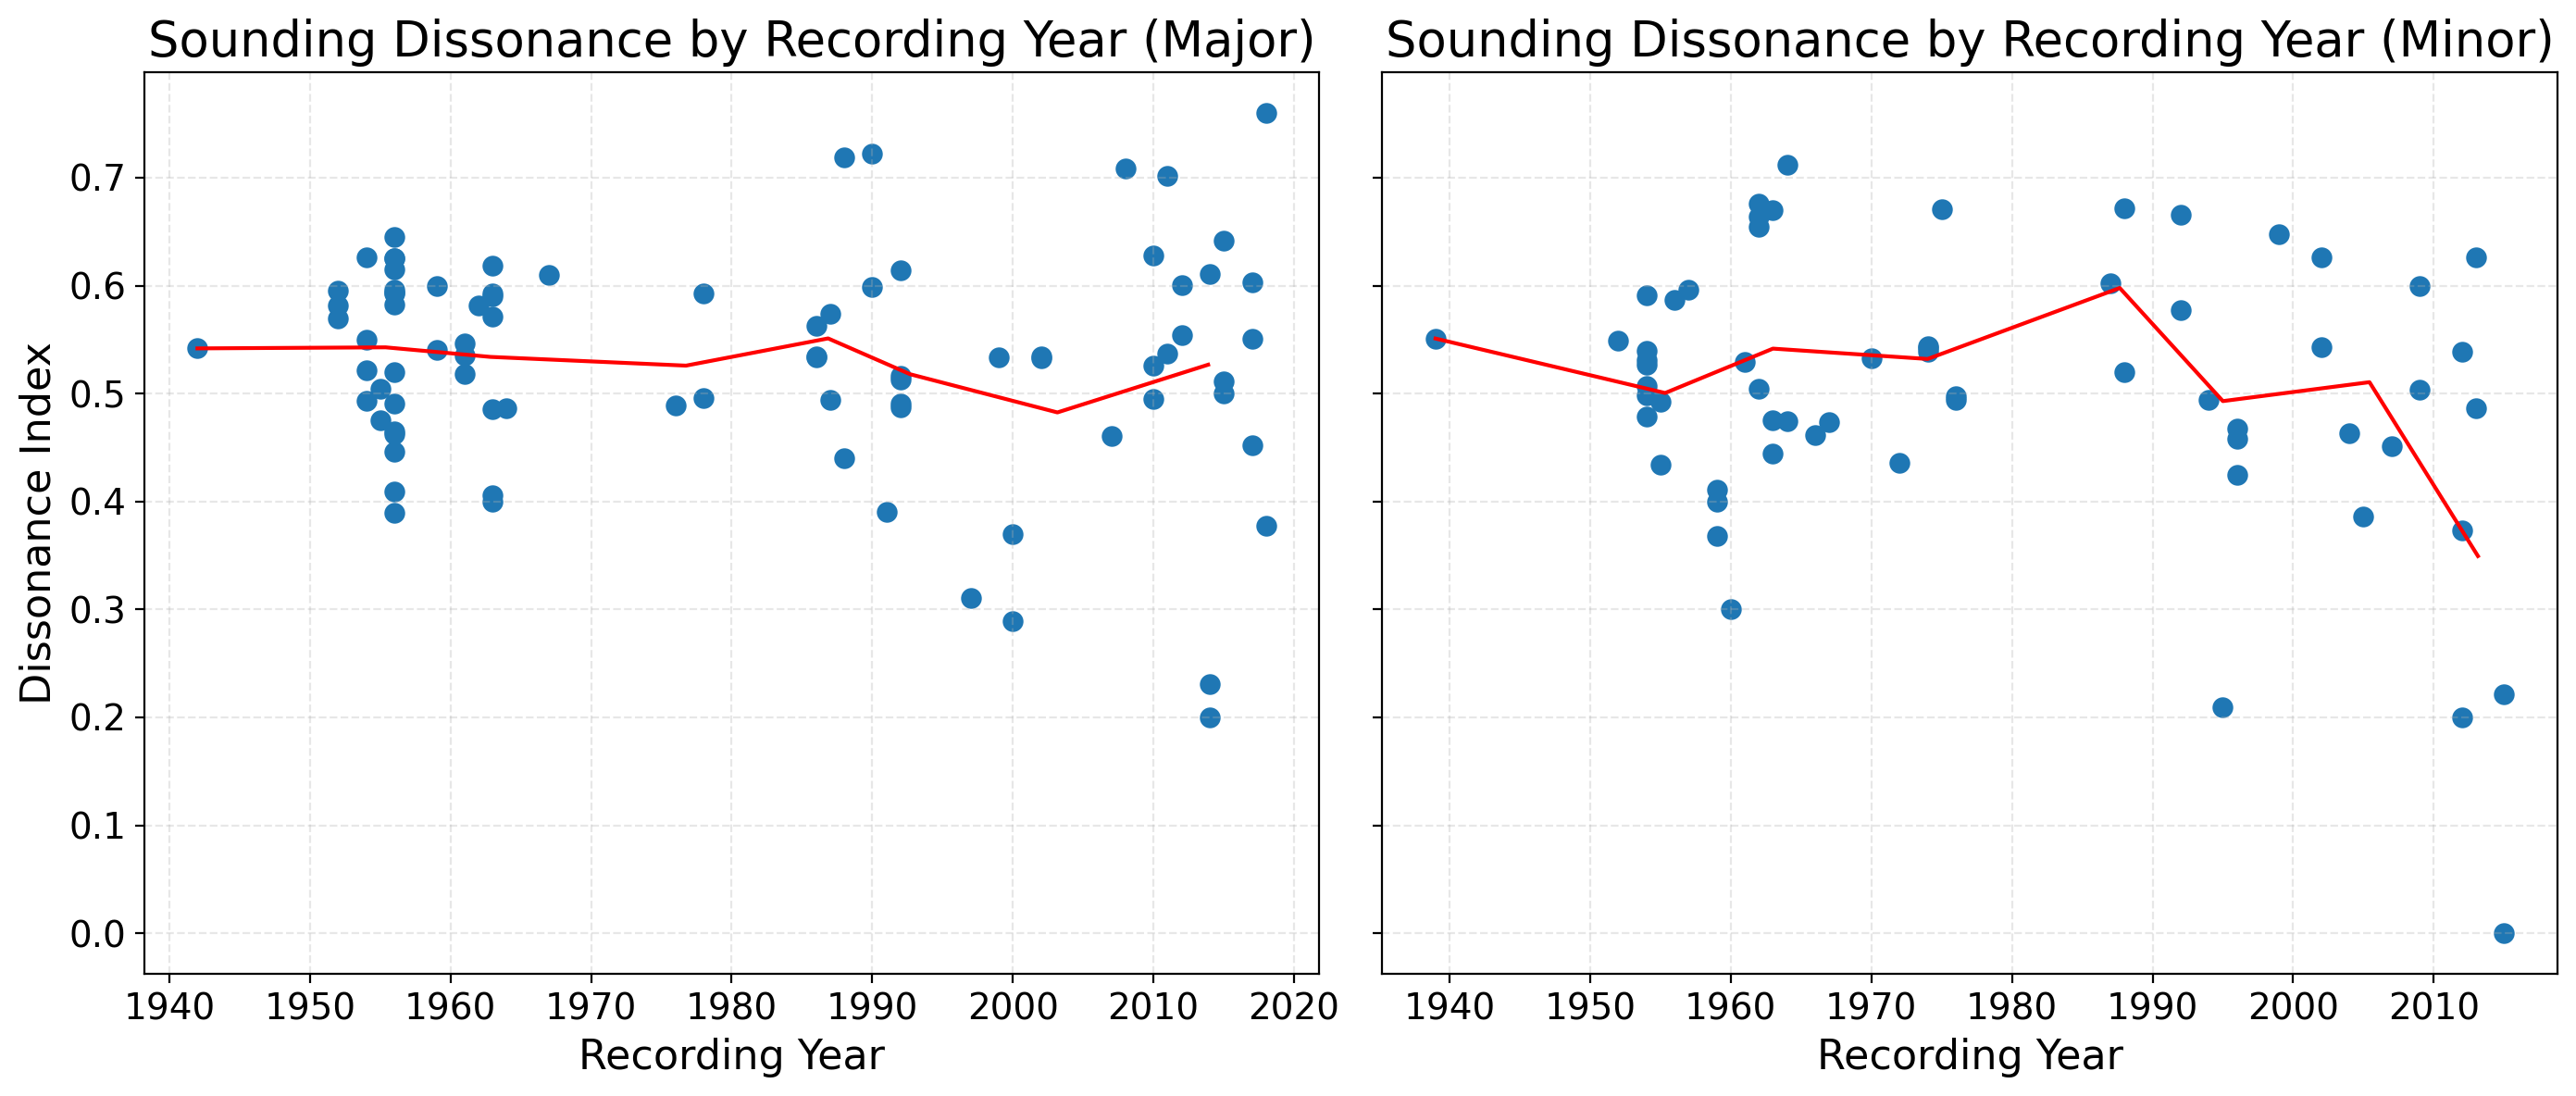

In [299]:
title = 'Sounding Dissonance by Recording Year'
fig,ax = ia.plot_dissonance(ILC_major, ILC_minor, title)

plt.tight_layout()
plt.savefig(f"../Results/AvgSoundingDissonanceIndex")
plt.show()

## In-label + sounding notes dissonance

In [257]:
major_notes = g.load_notes(major_metadata) 
minor_notes = g.load_notes(minor_metadata) 

In [261]:
def combine_notes(row):
    """
    Return list of notes, including sounding note and in-label set

    Args:
        row: row of df, usually generated from g.load_notes

    Return:
        list of notes
    """
    ils = row['ILS']
    note_val = row['note']
    
    if isinstance(ils, list):
        return ils + [note_val]
    else:
        return [note_val]
        
# Major: 
major_notes_labels = major_notes.copy()
major_notes_labels['notes_comb'] = major_notes_labels.apply(combine_notes, axis=1)
major_notes_labels['dissonance'] = major_notes_labels['notes_comb'].apply(ia.notes_to_dissonance)

minor_notes_labels = minor_notes.copy()
minor_notes_labels['notes_comb'] = minor_notes_labels.apply(combine_notes, axis=1)
minor_notes_labels['dissonance'] = minor_notes_labels['notes_comb'].apply(ia.notes_to_dissonance)

In [263]:
# Major: Calculate duration-weighted average dissonance for each piece
major_notes_labels['dissonance'] = major_notes_labels['dissonance'] * major_notes_labels['duration']
identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
major_notes_labels = major_notes_labels.groupby(by=identifier, as_index=False)[['dissonance', 'duration']].mean()
major_notes_labels['dissonance'] = major_notes_labels['dissonance'] / major_notes_labels['duration']

# Minor: Calculate duration-weighted average dissonance for each piece
minor_notes_labels['dissonance'] = minor_notes_labels['dissonance'] * minor_notes_labels['duration']
identifier = ['artist', 'workTitle', 'recording_year', 'year_bin']
minor_notes_labels = minor_notes_labels.groupby(by=identifier, as_index=False)[['dissonance', 'duration']].mean()
minor_notes_labels['dissonance'] = minor_notes_labels['dissonance'] / minor_notes_labels['duration']

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:564: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:565: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/intervalanalysis_utils.py:576: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/Users/

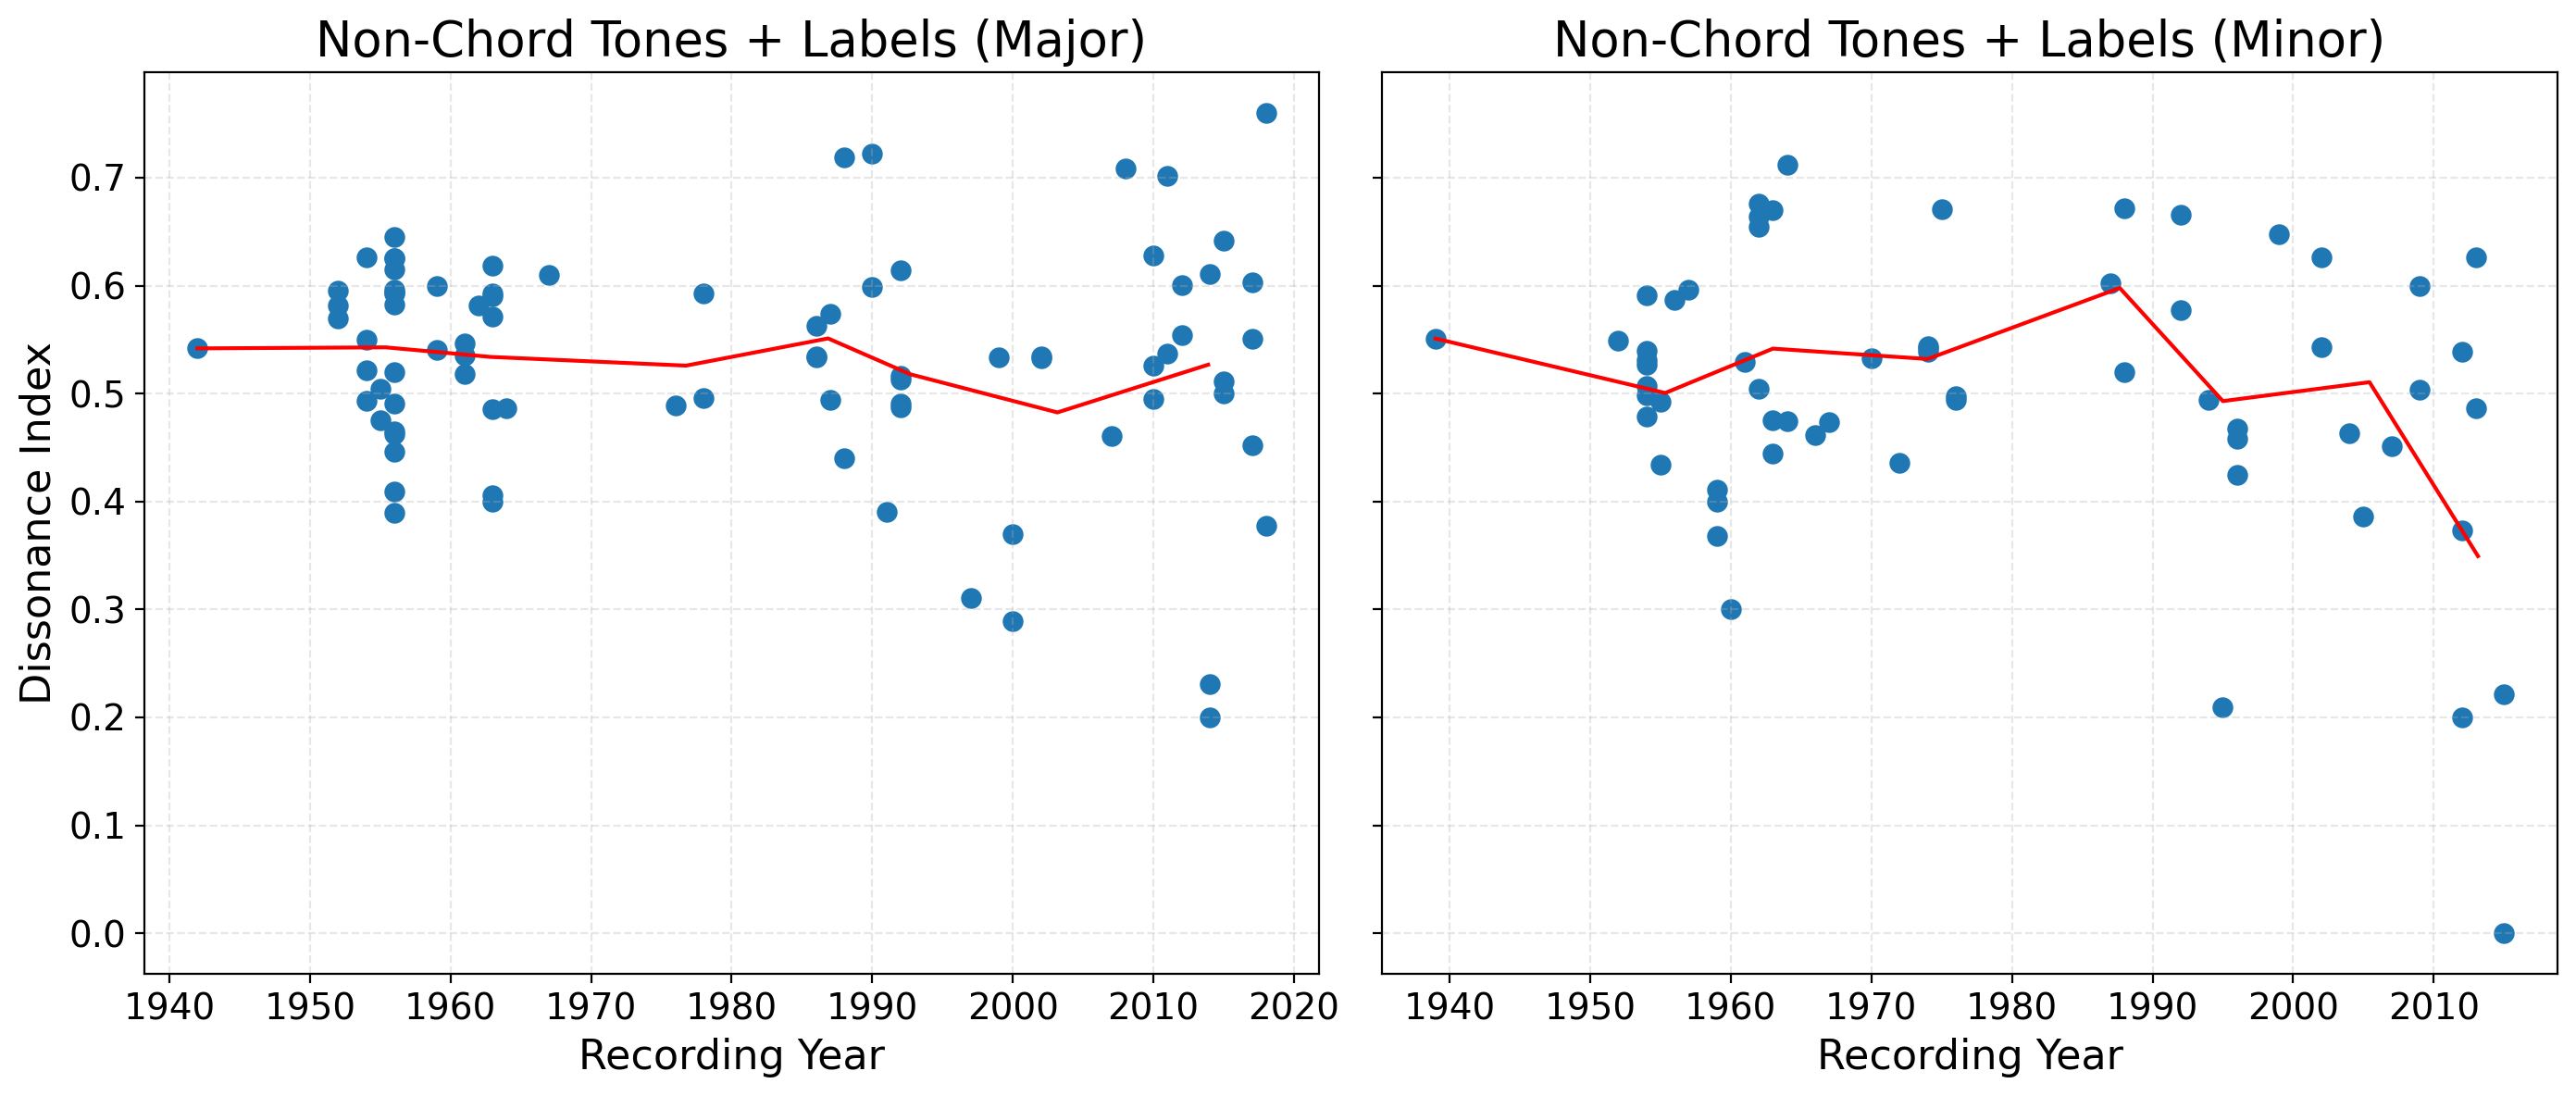

In [301]:
title = 'Non-Chord Tones + Labels'
fig,ax = ia.plot_dissonance(ILC_major, ILC_minor, title)

plt.tight_layout()
#plt.savefig(f"../Results/NonChordTone+LabelDissonanceIndex")
plt.show()

## Non Chord Tones

In [267]:
major_notes['note'] = major_notes['note'].apply(g.fix_flats)
minor_notes['note'] = minor_notes['note'].apply(g.fix_flats)

In [269]:
import math
def in_ILS(note_name, ils_list):
    if isinstance(ils_list, float) and math.isnan(ils_list):
        return np.nan

    n = m21.note.Note(note_name)

    if n.name in ils_list:
        return 1
    else:
        return 0

# Create column of 0,1 to identify which notes belong to the label
major_notes['in_ILS?'] = major_notes.apply(lambda row: in_ILS(row['note'], row['ILS']), axis=1)
minor_notes['in_ILS?'] = minor_notes.apply(lambda row: in_ILS(row['note'], row['ILS']), axis=1)

In [285]:
# Major: Find percentage of chord tones
major_notes_counts = major_notes.groupby(['year_bin', 'recording_year'], as_index=False)[['in_ILS?']].sum()
major_total_notes = major_notes.groupby(['year_bin', 'recording_year']).size().reset_index(name='total_notes')
major_notes_counts = major_notes_counts.merge(major_total_notes, on=['year_bin', 'recording_year'], how='left')
major_notes_counts['percentage'] = 100 * major_notes_counts['in_ILS?'] / major_notes_counts['total_notes']

# Minor: Find percentage of chord tones
minor_notes_counts = minor_notes.groupby(['year_bin', 'recording_year'], as_index=False)[['in_ILS?']].sum()
minor_total_notes = minor_notes.groupby(['year_bin', 'recording_year']).size().reset_index(name='total_notes')
minor_notes_counts = minor_notes_counts.merge(minor_total_notes, on=['year_bin', 'recording_year'], how='left')
minor_notes_counts['percentage'] = 100* minor_notes_counts['in_ILS?'] / minor_notes_counts['total_notes']

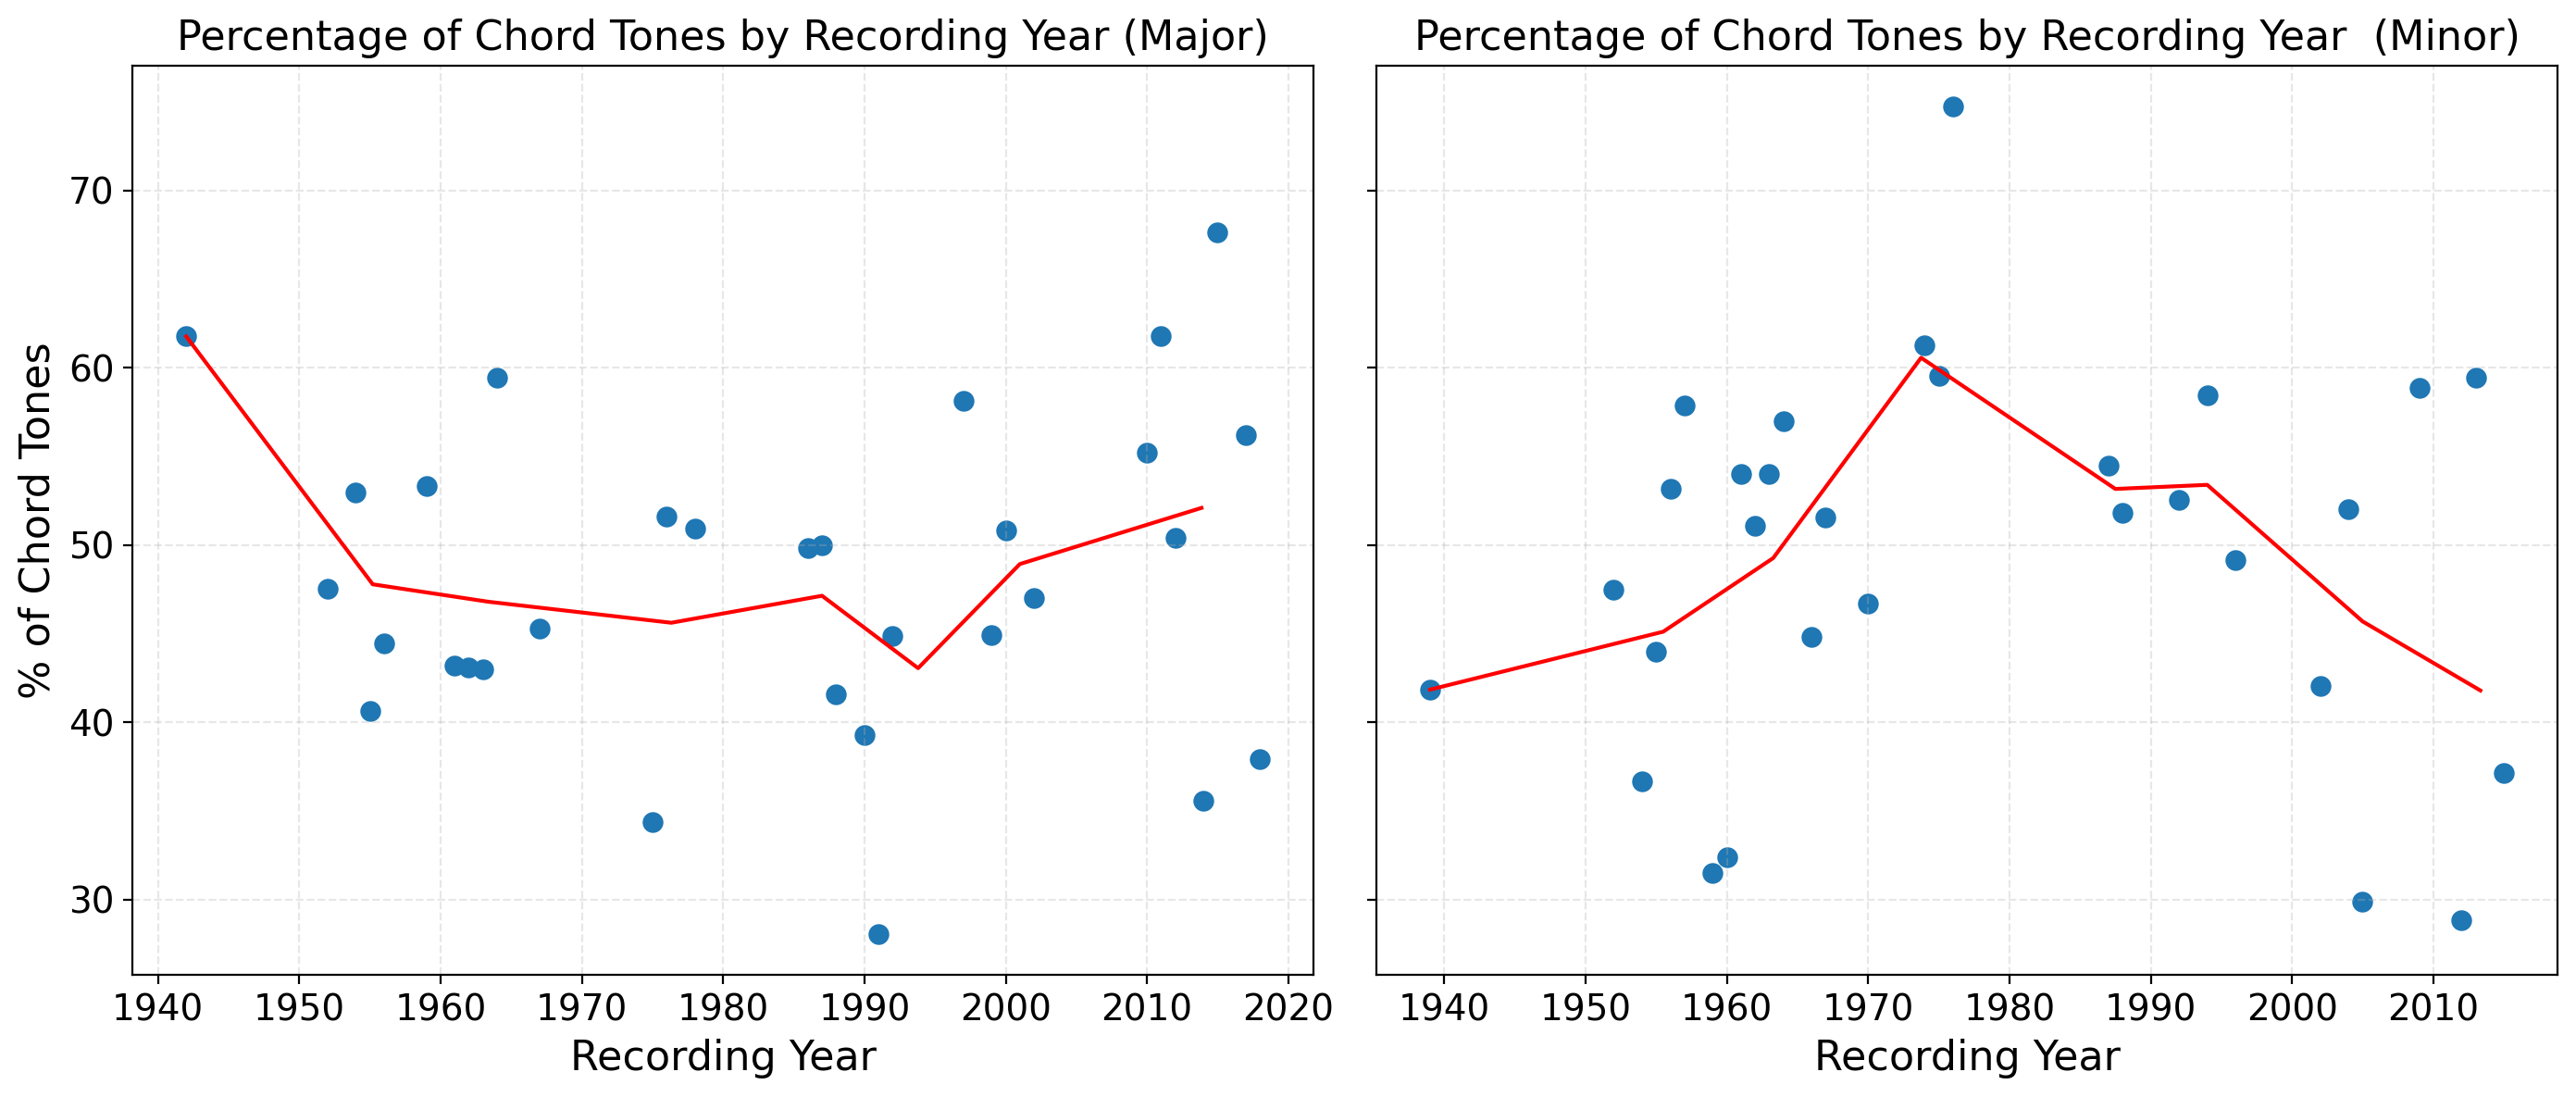

In [293]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot major
axes[0].scatter(major_notes_counts['recording_year'], major_notes_counts['percentage'], s=50)
    
axes[0].plot(major_notes_counts.groupby(by='year_bin', as_index=False).mean()['recording_year'], 
             major_notes_counts.groupby(by='year_bin', as_index=False).mean()['percentage'], color="red")
axes[0].set_title('Percentage of Chord Tones by Recording Year (Major)', fontsize=16)
axes[0].set_xlabel('Recording Year', fontsize=16)
axes[0].set_ylabel('% of Chord Tones', fontsize=16)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].tick_params(axis='both', which='major', labelsize=14)


# Plot minor
axes[1].scatter(minor_notes_counts['recording_year'], minor_notes_counts['percentage'], s=50)
    
axes[1].plot(minor_notes_counts.groupby(by='year_bin', as_index=False).mean()['recording_year'], 
             minor_notes_counts.groupby(by='year_bin', as_index=False).mean()['percentage'], color="red")
axes[1].set_title('Percentage of Chord Tones by Recording Year  (Minor)', fontsize=16)
axes[1].set_xlabel('Recording Year', fontsize=16)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
#plt.savefig(f"../Results/PercentageChordTones")
plt.show()